# Zyro AI/ML Internship - Week 1
## Environment, Tooling & Machine Learning Verification Notebook

**Internship:** Zyro AI/ML Internship  
**Week:** 01  
**Purpose:** Verify Python installation, virtual environment setup, required AI/ML libraries, data handling, visualization, and basic machine learning model execution.

---  
### 1. System & Environment Verification
Let's check Python executable, version, virtual environment status, and Git version.

In [1]:
import sys
import subprocess
import os

print("=" * 60)
print("SYSTEM INFORMATION & ENVIRONMENT STATUS")
print("=" * 60)
print(f"Python Executable : {sys.executable}")
print(f"Python Version    : {sys.version.split()[0]}")
print(f"Prefix Path       : {sys.prefix}")
is_venv = sys.prefix != sys.base_prefix
print(f"Virtual Env Active: {'YES (' + sys.prefix + ')' if is_venv else 'NO (Global / Base)'}")

# Check Git version
try:
    git_version = subprocess.check_output(['git', '--version'], text=True).strip()
    print(f"Git Version       : {git_version}")
except Exception as e:
    print(f"Git Check         : Could not execute git ({e})")
print("=" * 60)

SYSTEM INFORMATION & ENVIRONMENT STATUS
Python Executable : C:\Users\rajan\OneDrive\Desktop\Internships\zyro-aiml-internship\.venv\Scripts\python.exe
Python Version    : 3.13.14
Prefix Path       : C:\Users\rajan\OneDrive\Desktop\Internships\zyro-aiml-internship\.venv
Virtual Env Active: YES (C:\Users\rajan\OneDrive\Desktop\Internships\zyro-aiml-internship\.venv)
Git Version       : git version 2.54.0.windows.1


---  
### 2. Required AI/ML Libraries Verification
Import NumPy, Pandas, Matplotlib, Seaborn, and Scikit-Learn to ensure all dependencies are correctly installed.

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("=" * 50)
print("INSTALLED LIBRARY VERSIONS")
print("=" * 50)
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Matplotlib   : {matplotlib.__version__}")
print(f"Seaborn      : {sns.__version__}")
print(f"Scikit-Learn : {sklearn.__version__}")
print("=" * 50)
print(" All required AI/ML libraries imported successfully!")

INSTALLED LIBRARY VERSIONS
NumPy        : 2.5.2
Pandas       : 3.0.5
Matplotlib   : 3.11.1
Seaborn      : 0.13.2
Scikit-Learn : 1.9.0
 All required AI/ML libraries imported successfully!


---  
### 3. Data Handling & Exploration with Pandas and NumPy
Load the classic Iris dataset from `sklearn.datasets` and inspect the structured DataFrame.

In [3]:
from sklearn.datasets import load_iris

# Load dataset into pandas DataFrame
iris = load_iris(as_frame=True)
df = iris.frame

# Map target integers to class names
df['species'] = df['target'].map(lambda x: iris.target_names[x])

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 Records:")
df.head()

Dataset Shape: 150 rows, 6 columns

First 5 Records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
# Statistical summary of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
target,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


---  
### 4. Data Visualization with Matplotlib & Seaborn
Create plots to visualize feature distributions across the different Iris species.

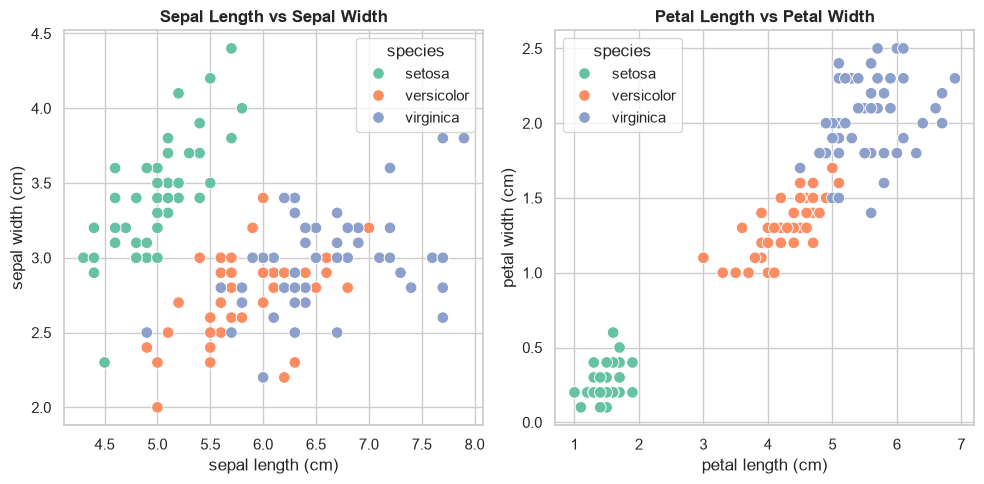

In [5]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Subplot 1: Sepal Dimensions
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species",
    palette="Set2",
    s=70
)
plt.title("Sepal Length vs Sepal Width", fontsize=12, fontweight="bold")

# Subplot 2: Petal Dimensions
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    palette="Set2",
    s=70
)
plt.title("Petal Length vs Petal Width", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

---  
### 5. Machine Learning Model Training & Evaluation
Train a `RandomForestClassifier` to classify flower species based on floral measurements.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Features and Target
X = iris.data
y = iris.target

# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize and train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f" Random Forest Classifier Test Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

 Random Forest Classifier Test Accuracy: 90.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



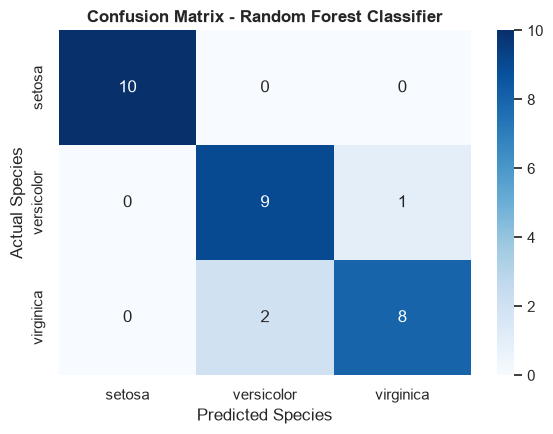

In [7]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.title("Confusion Matrix - Random Forest Classifier", fontsize=12, fontweight="bold")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.tight_layout()
plt.show()

---  
### 6. Verification Summary & Status Check
All tools, libraries, and basic machine learning workflows have completed successfully.

In [8]:
checklist = {
    "Python 3.x Installed": True,
    "Git Installed": True,
    "Virtual Environment Active": is_venv,
    "AI/ML Libraries Installed (NumPy, Pandas, Matplotlib, Seaborn, Scikit-Learn)": True,
    "Jupyter Notebook Support Working": True,
    "Machine Learning Pipeline Executed Successfully": True
}

print("=" * 65)
print("ZYRO AI/ML INTERNSHIP - WEEK 1 VERIFICATION SUMMARY")
print("=" * 65)
for item, status in checklist.items():
    icon = "[✓]" if status else "[✗]"
    print(f"{icon} {item}")
print("=" * 65)
print(" Status: READY FOR WEEK 1 SUBMISSION!")

ZYRO AI/ML INTERNSHIP - WEEK 1 VERIFICATION SUMMARY
[✓] Python 3.x Installed
[✓] Git Installed
[✓] Virtual Environment Active
[✓] AI/ML Libraries Installed (NumPy, Pandas, Matplotlib, Seaborn, Scikit-Learn)
[✓] Jupyter Notebook Support Working
[✓] Machine Learning Pipeline Executed Successfully
 Status: READY FOR WEEK 1 SUBMISSION!
